In [64]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, LogStretch, SqrtStretch
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from photutils import DAOStarFinder
from astropy.stats import sigma_clipped_stats
from astropy.wcs.utils import proj_plane_pixel_scales
from glob import glob
import os
from pprint import pprint as print

plt.style.use("science")
params = {
         'axes.labelsize': 15,
         'axes.titlesize': 25,
         'ytick.labelsize' :12,
         'xtick.labelsize' :12,
         'xtick.major.size': 8,
         'xtick.minor.size': 4,
         'xtick.major.width': 1,
         'xtick.minor.width': 1,
         'ytick.color': "w",
         'xtick.color': "w",
         'axes.labelcolor': "k",
         'ytick.labelcolor' : "k",
         'xtick.labelcolor' : "k",
         }

/tmp/ipykernel_412196/2774569714.py:8: DeprecationWarning: `photutils.DAOStarFinder` is a deprecated alias for `photutils.detection.DAOStarFinder` and will be removed in the future. Instead, please use `from photutils.detection import DAOStarFinder` to silence this warning.
  from photutils import DAOStarFinder


In [21]:
base_path = "/media/alexandre/Seagate/Data/Joseph_targets/"

# Create SkyCoord objects
J030000 = SkyCoord('03h00m00.573s', '+00d48m28.01s', frame='icrs')
J085053 = SkyCoord('08h50m53.125s', '+44d51m22.50s', frame='icrs')
J102036 = SkyCoord('10h20m36.103s', '+60d23m38.96s', frame='icrs')
J105102 = SkyCoord('10h51m02.775s', '+52d50m49.86s', frame='icrs')
J112526 = SkyCoord('11h25m26.126s', '+00d29m01.32s', frame='icrs')

# J030000: PSF dominated, unanalyzable
J030000_drz_path = base_path + 'hst_wfc3_sdssj030000/HST/ICL901010/icl901010_drz.fits'
# J085053: Galaxy found, easiest to analyze.
J085053_drz_path = base_path + 'hst_wfc3_sdssj085053/HST/IB5T05010/ib5t05010_drz.fits'
# J102036: Disturbed galaxy.
J102036_drz_path = base_path + 'hst_wfc3_sdssj102036/HST/ICL903010/icl903010_drz.fits'
# J105102: Galaxy found, easiest to analyze.
J105102_drz_path = base_path + 'hst_wfc3_sdssj105102/HST/IB5T10010/ib5t10010_drz.fits'
# J112526: PSF dominated, unanalyzable.
J112526_drz_path = base_path + 'hst_wfc3_sdssj112526/HST/ICL904010/icl904010_drz.fits'

# Define the paths
base_paths = [base_path + 'hst_wfc3_sdssj030000/HST/ICL901010/',
              base_path + 'hst_wfc3_sdssj085053/HST/IB5T05010/',
              base_path + 'hst_wfc3_sdssj102036/HST/ICL903010/',
              base_path + 'hst_wfc3_sdssj105102/HST/IB5T10010/',
              base_path + 'hst_wfc3_sdssj112526/HST/ICL904010/']

# Create lists of 'flt' fits files
flt_paths = [glob(p + '*_flt.fits') for p in base_paths]

# The 'flt_paths' variable now contains five lists, one for each base path,
# with the paths to the 'flt' fits files. You can access them like this:
J030000_flt_paths, J085053_flt_paths, J102036_flt_paths, J105102_flt_paths, J112526_flt_paths = flt_paths

# Perusing DRZ files

## First, explore one of the targets

In [27]:
data = fits.open(J085053_drz_path)
wcs = WCS(data["SCI"].header)
coord = J085053
# data["SCI"].header

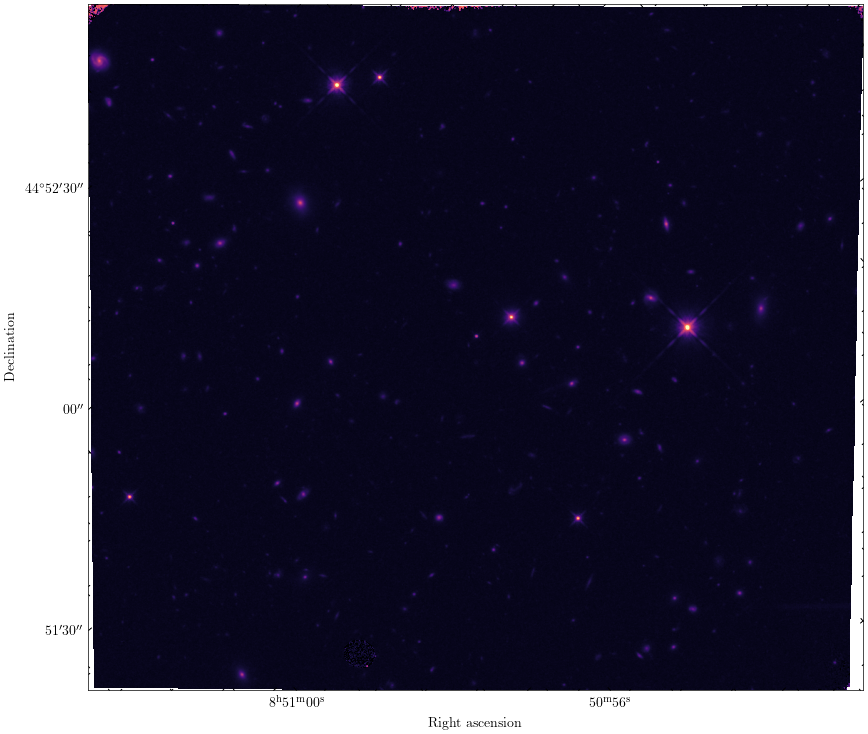

In [26]:
fig = plt.figure(figsize=(10, 10))
fig.add_subplot(projection=wcs)
plt.imshow(data["SCI"].data, cmap="magma", norm=ImageNormalize(vmax=500, vmin=0.5, stretch=LogStretch()))
plt.xlabel("Right ascension")
plt.ylabel("Declination")

In [36]:
size = 64 * u.pixel
cutout = Cutout2D(data["SCI"].data, coord, size, wcs=wcs)

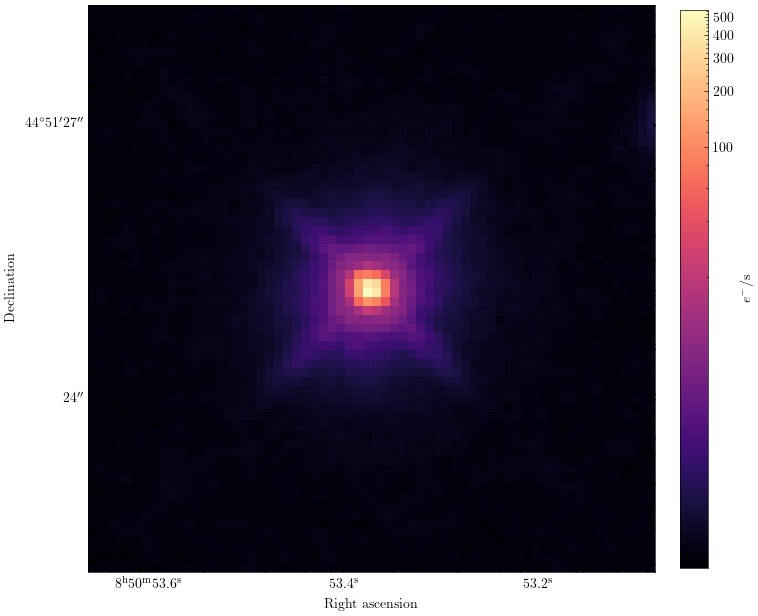

In [37]:
# wcs = WCS(data["SCI"].header)
fig = plt.figure(figsize=(8, 8))
fig.add_subplot(projection=cutout.wcs)
plt.imshow(cutout.data, cmap="magma", norm=ImageNormalize(stretch=LogStretch()))
plt.colorbar(label=r"$e^{-}$/s", fraction=0.045, pad=0.04)
plt.ylabel("Declination")
plt.xlabel("Right ascension")

## Collect all cutouts in a more systematic way

In [38]:
# Do this for every target and plot their flts

# Dictionary of SkyCoord objects
coords = {
    "J030000": J030000,
    "J085053": J085053,
    "J102036": J102036,
    "J105102": J105102,
    "J112526": J112526
}
# Dictionary of drz file paths
drz_paths = {
    "J030000": J030000_drz_path,
    "J085053": J085053_drz_path,
    "J102036": J102036_drz_path,
    "J105102": J105102_drz_path,
    "J112526": J112526_drz_path
}
# Define the size of the cutout
size = 64 * u.pixel
# Create a dictionary to hold the cutouts
cutouts = {}
# Loop over the coords and paths
for key in coords.keys():
    # Load the data
    data = fits.open(drz_paths[key])
    # Extract the WCS
    wcs = WCS(data["SCI"].header)
    # Perform the cutout
    cutout = Cutout2D(data["SCI"].data, coords[key], size, wcs=wcs)
    # Store the cutout in the dictionary
    cutouts[key] = cutout

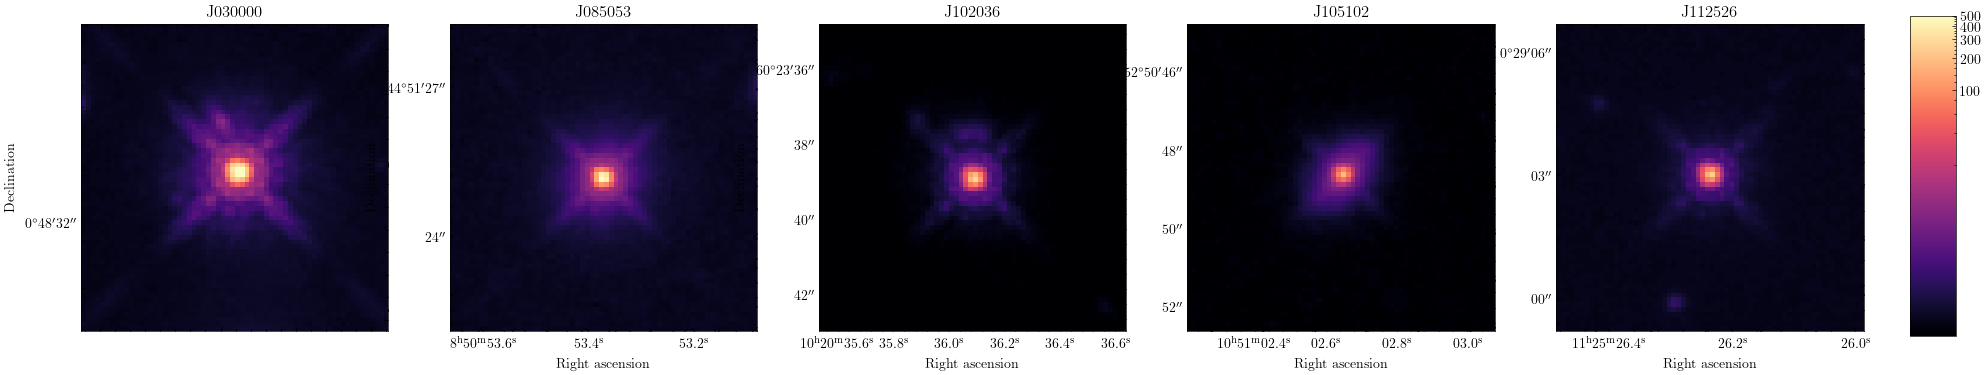

In [44]:
# Create a figure
fig = plt.figure(figsize=(23, 4))
# Number of subplots
n = len(cutouts)
# Loop over the cutouts and create a subplot for each
for i, (key, cutout) in enumerate(cutouts.items()):
    ax = fig.add_subplot(1, n, i+1, projection=cutout.wcs)
    ax.set_ylabel("Declination")
    ax.set_xlabel("Right ascension")
    im = ax.imshow(cutout.data, cmap="magma", norm=ImageNormalize(stretch=LogStretch(), vmax=500, vmin=0.5))
    ax.set_title(key)
ax2 = fig.add_axes([0.92, 0.1, 0.02, 0.8])
fig.colorbar(im, cax=ax2)

# Collating FLT files for analysis 

In [ ]:
fits.open(flt_paths[key])[0].header

In [75]:
for key in flt_paths.keys():
    print(key)
    for i in range(len(flt_paths[key])):
        data = fits.open(flt_paths[key][i])
        date = data[0].header["DATE-OBS"]
        time = data[0].header["TIME-OBS"]
        print(f"Date {date}, time {time}")

'J030000'
'Date 2014-12-08, time 14:56:51'
'Date 2014-12-08, time 15:02:14'
'Date 2014-12-08, time 15:07:37'
'Date 2014-12-08, time 15:13:08'
'Date 2014-12-08, time 15:18:31'
'Date 2014-12-08, time 15:23:54'
'Date 2014-12-08, time 15:29:25'
'Date 2014-12-08, time 15:34:48'
'Date 2014-12-08, time 15:40:11'
'J085053'
'Date 2010-04-09, time 07:20:28'
'Date 2010-04-09, time 07:29:03'
'J102036'
'Date 2014-10-15, time 19:49:51'
'Date 2014-10-15, time 19:55:14'
'Date 2014-10-15, time 20:00:37'
'Date 2014-10-15, time 20:06:08'
'Date 2014-10-15, time 20:11:31'
'Date 2014-10-15, time 20:16:54'
'Date 2014-10-15, time 20:22:25'
'Date 2014-10-15, time 20:27:48'
'Date 2014-10-15, time 20:33:11'
'J105102'
'Date 2009-11-15, time 21:56:40'
'Date 2009-11-15, time 22:06:05'
'J112526'
'Date 2015-05-05, time 23:43:44'
'Date 2015-05-05, time 23:49:07'
'Date 2015-05-05, time 23:54:30'
'Date 2015-05-06, time 00:00:01'
'Date 2015-05-06, time 00:05:24'
'Date 2015-05-06, time 00:10:47'
'Date 2015-05-06, time 00:

In [53]:
# Dictionary of lists of flt file paths
flt_paths = {
    "J030000": J030000_flt_paths,
    "J085053": J085053_flt_paths,
    "J102036": J102036_flt_paths,
    "J105102": J105102_flt_paths,
    "J112526": J112526_flt_paths
}

# Create a dictionary to hold the cutouts
cutouts_flt = {}
# Define the size of the cutout
size = 64 * u.pixel
# Loop over the coords and paths
for key in coords.keys():
    cutouts_flt[key] = []  # Initialize the list of cutouts for this key
    for path in flt_paths[key]:
        # Load the data
        data = fits.open(path)
        # Extract the WCS
        wcs = WCS(data["SCI"].header)
        # Perform the cutout
        cutout = Cutout2D(data["SCI"].data, coords[key], size, wcs=wcs)
        # Add the cutout to the list
        cutouts_flt[key].append(cutout)


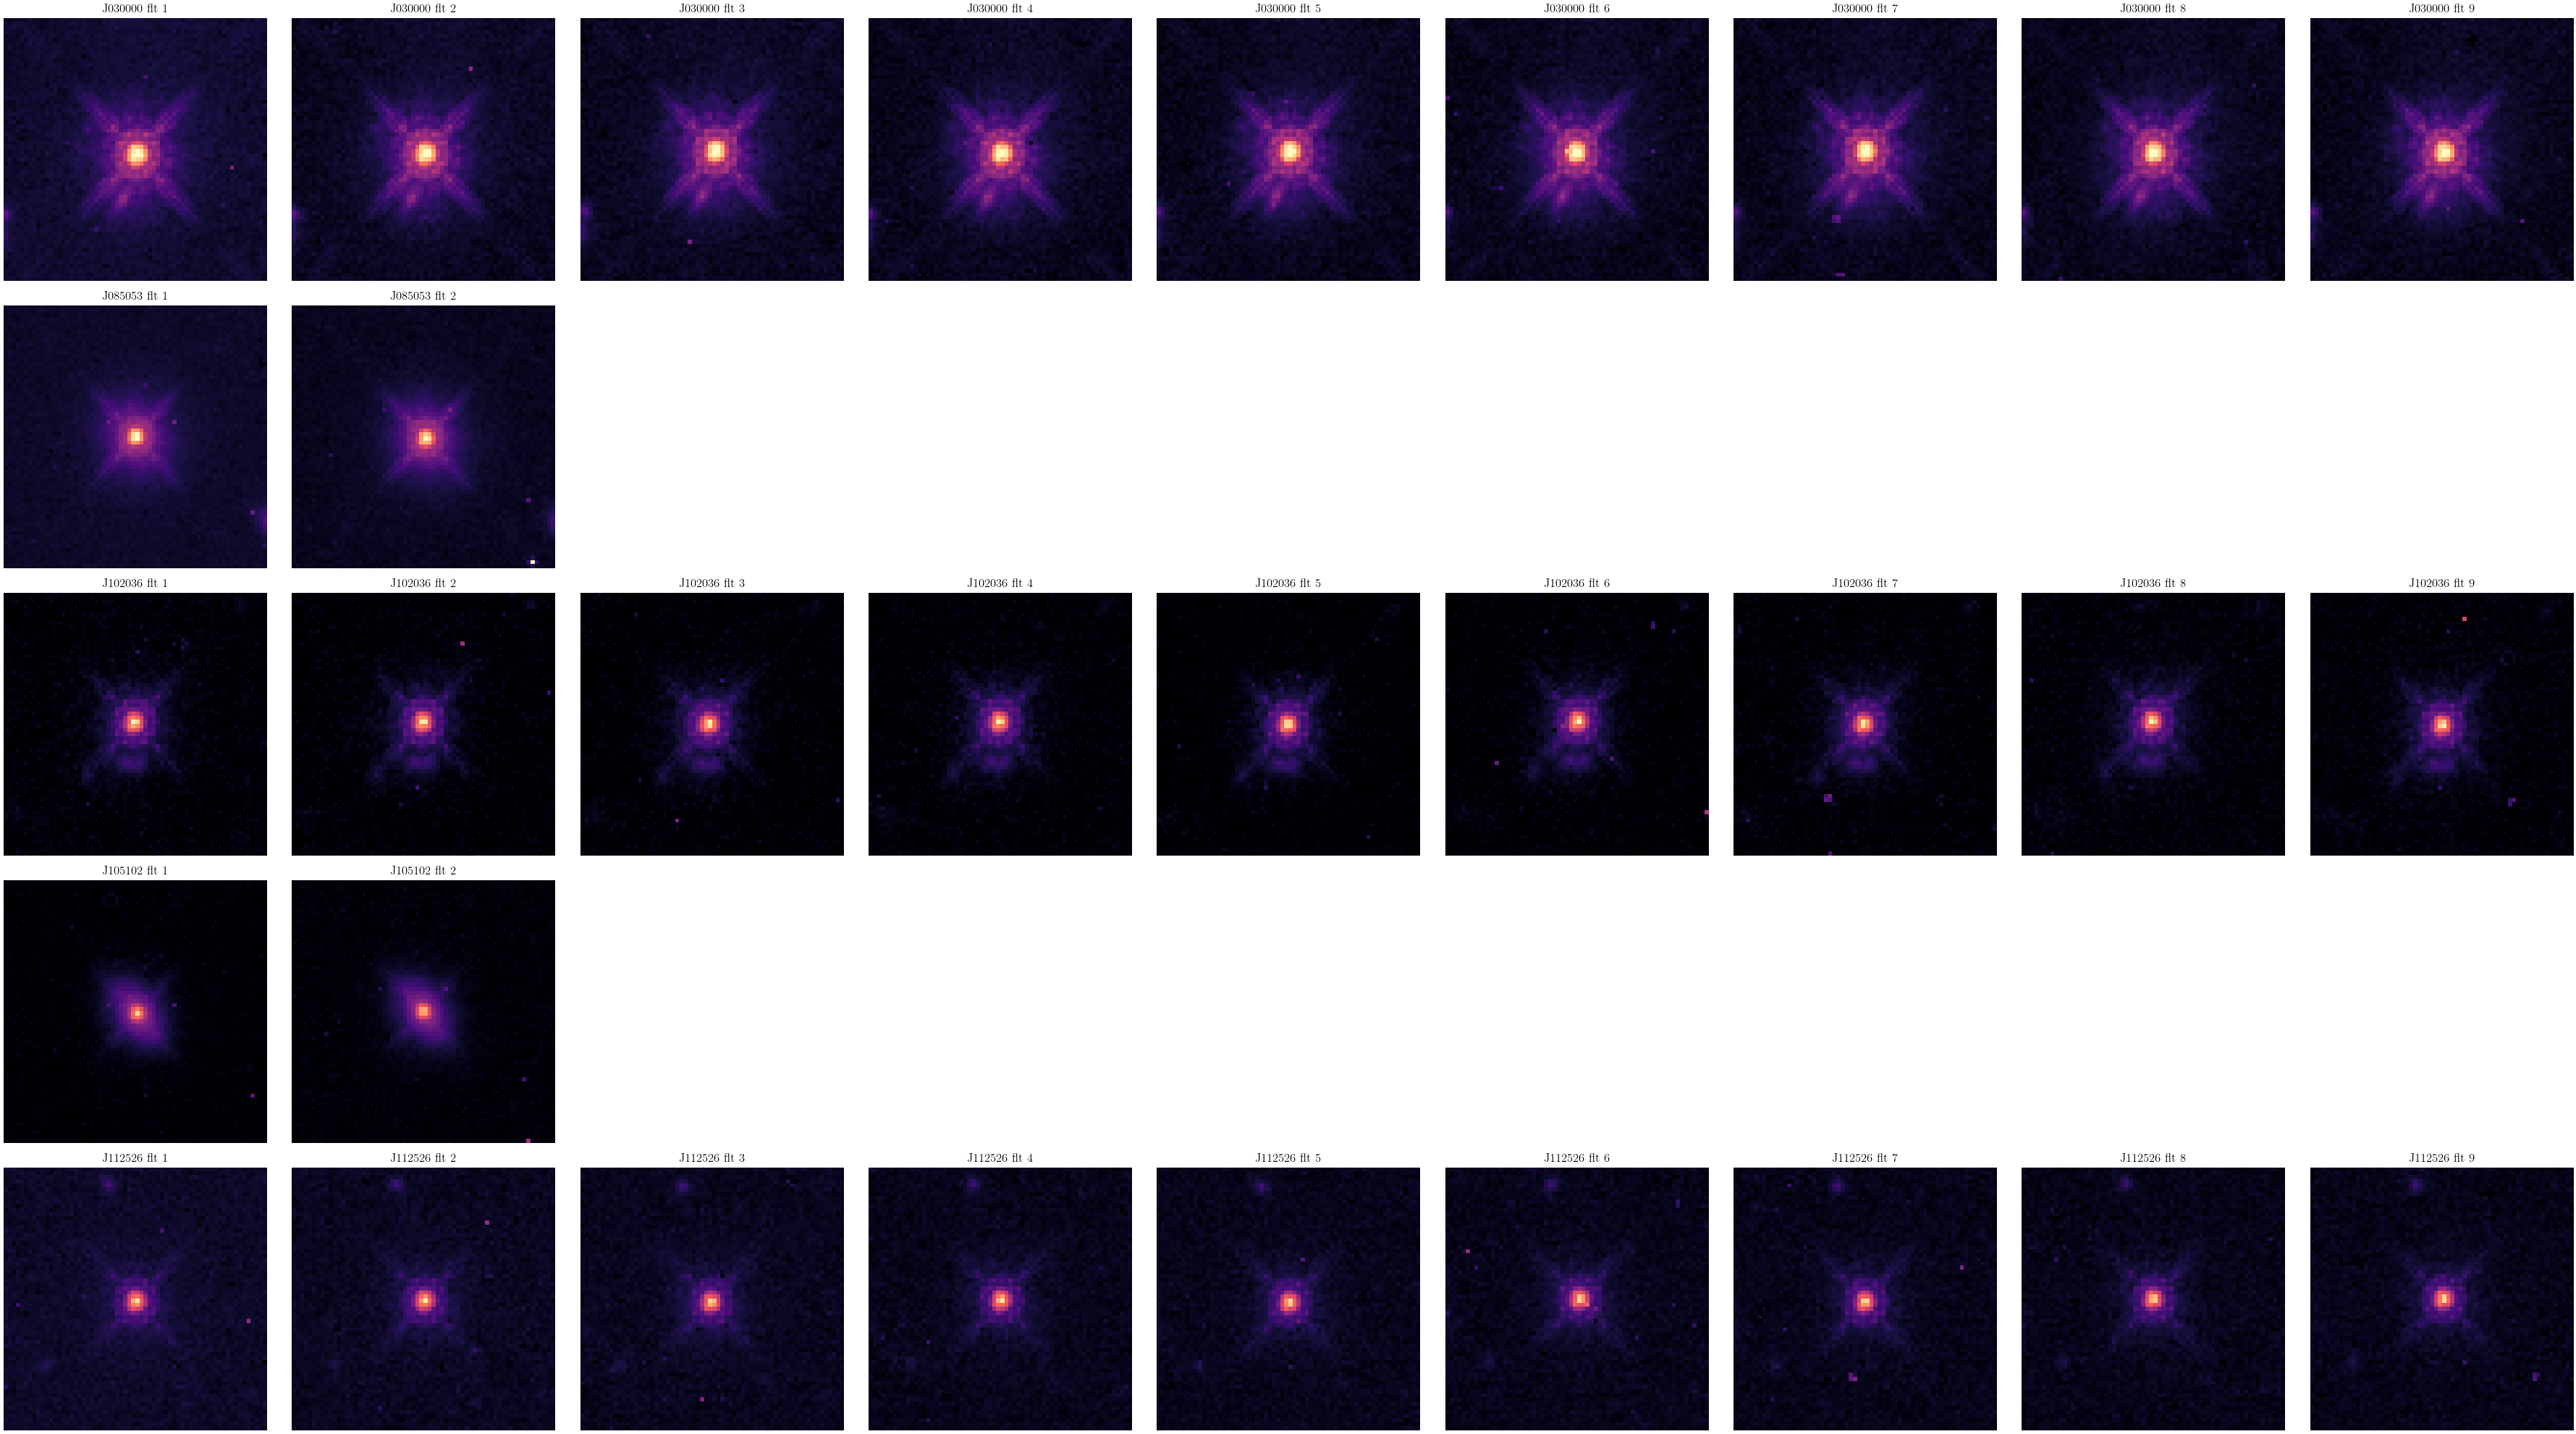

In [55]:
# Get the maximum number of flt files for any target
max_flt_files = max(len(cutouts_flt[key]) for key in cutouts_flt)

# Create a figure
fig, axs = plt.subplots(len(cutouts_flt), max_flt_files, figsize=(max_flt_files*4, 20), squeeze=False)

# Loop over the targets
for i, (key, cutouts) in enumerate(cutouts_flt.items()):
    # Loop over the cutouts for this target
    for j, cutout in enumerate(cutouts):
        # Create a subplot for this cutout
        ax = axs[i, j]
        im = ax.imshow(cutout.data, cmap="magma", norm=ImageNormalize(stretch=LogStretch(), vmax=500, vmin=0.5))
        ax.set_title(f"{key} flt {j+1}")
        ax.axis("off")

# Remove empty subplots
for ax in axs.flatten():
    if not len(ax.images):
        fig.delaxes(ax)

plt.tight_layout()